In [10]:
import sys
import os
os.chdir('/zhome/71/c/146676/main/')
import time
import SimpleITK as sitk
import numpy as np
from astropy.io import fits
from helpers import module_auxiliary as ma
import tifffile
from multiprocessing import Pool
import matplotlib.pyplot as plt
from helpers import extended_data as ed
from cil.recon import FBP
#from cil.plugins.astra import FBP
from cil.framework import AcquisitionGeometry, AcquisitionData, ImageGeometry, ImageData, BlockDataContainer
from cil.plugins.ccpi_regularisation.functions import FGP_TV
from cil.optimisation.functions import L2NormSquared, L1Norm, BlockFunction, MixedL21Norm, IndicatorBox, TotalVariation, LeastSquares
from cil.optimisation.operators import BlockOperator, GradientOperator, IdentityOperator, FiniteDifferenceOperator
from cil.optimisation.algorithms import CGLS, SIRT, GD, FISTA, ISTA, PDHG, SPDHG
from cil.plugins.astra.operators import ProjectionOperator
from cil.optimisation.functions import IndicatorBox, MixedL21Norm, L2NormSquared, \
                                       BlockFunction, L1Norm, LeastSquares, \
                                       OperatorCompositionFunction, TotalVariation, \
                                       ZeroFunction
from cil.optimisation.operators import BlockOperator, GradientOperator,\
                                       GradientOperator
import h5py
from cil.utilities.display import show_geometry
from scipy.ndimage import uniform_filter1d
from cil.processors import Slicer

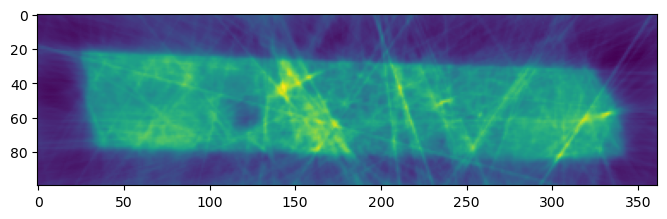

In [53]:
import nibabel as nib

# Load the NIfTI file
img = nib.load("/dtu-compute/msaca/sliceA_diffraction/own_reconstructions/cgls_alphadc_10000.nii")

# Get the NumPy array
N = 600
recon= img.get_fdata()
plt.figure(figsize=(8,8))
plt.imshow(recon[N])
#plt.clim([-0.01*50/N,0.02*50/N])

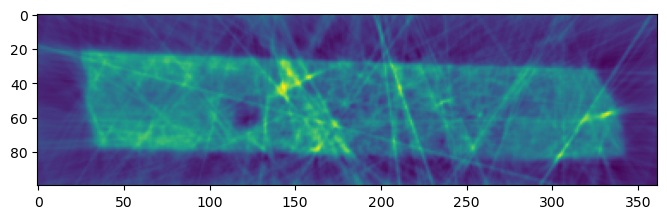

In [60]:
import nibabel as nib

# Load the NIfTI file
img = nib.load("/dtu-compute/msaca/sliceA_diffraction/own_reconstructions/cgls_alphadc_5000.nii")

# Get the NumPy array
N = 600
recon= img.get_fdata()
plt.figure(figsize=(8,8))
plt.imshow(recon[N])
#plt.clim([-0.01*50/N,0.02*50/N])

0.26223061340533604
12.914885


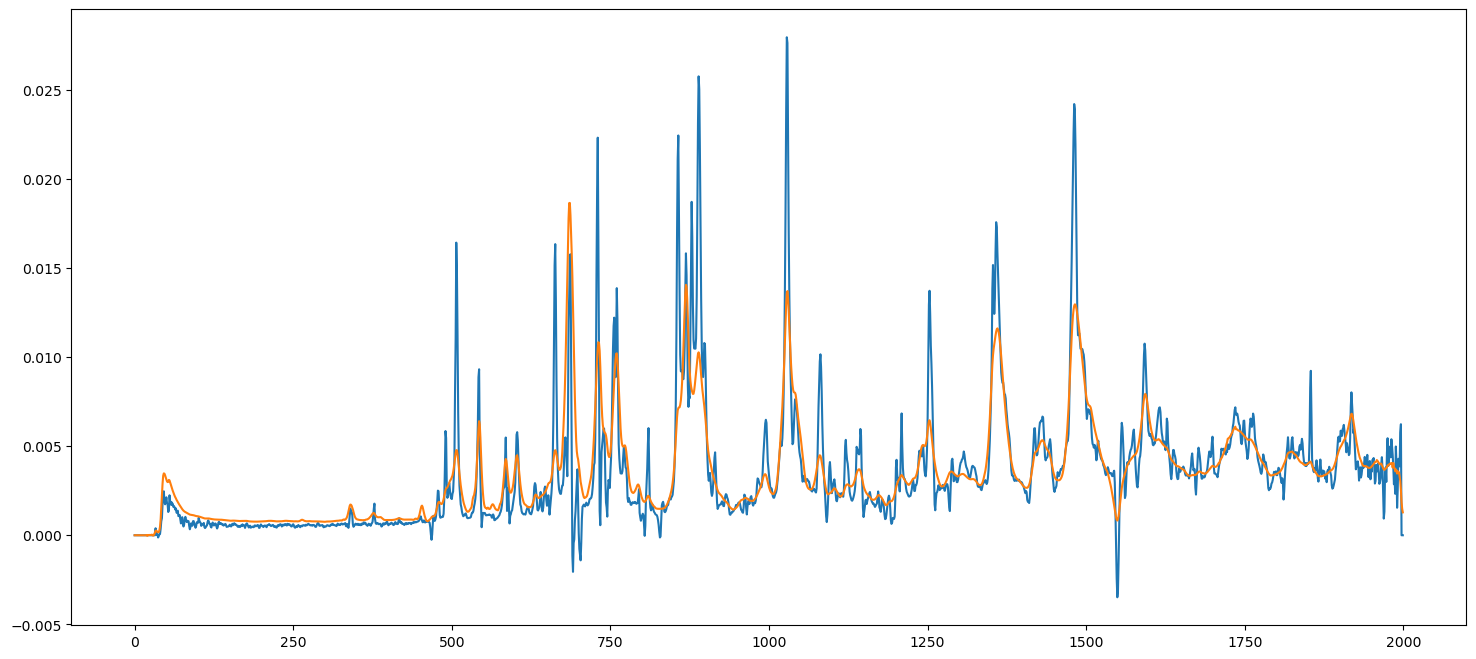

In [56]:
plt.figure(figsize=(18,8))
#plt.plot(recon[:,40,150])
plt.plot(recon_gridrec[:,60,100]/14)
plt.plot(recon[:,60,100])
print(np.sum(np.abs(np.diff(recon[:,60,100]))))
print(np.sum(np.abs(np.diff(recon_gridrec[:,60,100]))))

In [4]:
c0 = 0
c1 = 2000

y0 = 130
y1 = 230

pad = 30

In [11]:
def zero_pad_3d(array: np.ndarray, N: int,value=0) -> np.ndarray:
    """
    Pads a 3D NumPy array with zeros along the last two dimensions by N pixels.
    The first dimension (axis=0) remains unchanged.

    Parameters:
    array (np.ndarray): Input 3D array.
    N (int): Number of pixels to pad along the last two dimensions.

    Returns:
    np.ndarray: Zero-padded 3D array.
    """
    if N < 0:
        raise ValueError("Padding size N must be non-negative")
    
    pad_width = ((0, 0), (0, 0), (N, N))  # No padding on axis=0, N on other axes
    return np.pad(array, pad_width, mode='constant', constant_values=0)


In [12]:
# Open the h5 file in read mode
with h5py.File('/dtu-compute/msaca/sliceA_diffraction/xrd_ct_integrated/scan-0339_pilatus_integrated.h5', 'r') as file:
    # Check the keys in the file (this shows the main datasets or groups)
    
    # Access a dataset or group (replace 'your_dataset' with the correct key)
    dataset = file['entry']['data1d']['I'][:][:,c0:c1]  # Replace 'your_dataset' with the actual name of the dataset
    dataset  = dataset.reshape(181, 362, c1-c0).transpose([2,0,1])
    two_theta = file['entry']['data1d']['2th'][:]

# Open the h5 file in read mode
with h5py.File('/dtu-compute/msaca/sliceA_diffraction/xrd_reconstructions/scan-339_recon.h5', 'r') as file:
    # Check the keys in the file (this shows the main datasets or groups)
    
    # Access a dataset or group (replace 'your_dataset' with the correct key)
    recon_gridrec = (file['reconstructed']['gridrec'][:]/500).transpose([2,0,1])[c0:c1,y0:y1]
     # Replace 'your_dataset' with the actual name of the dataset
     
    # Open the h5 file in read mode
with h5py.File('/dtu-compute/msaca/sliceA_diffraction/xrd_attenuation/scan-0339_xspress3-dtc-2d.h5', 'r') as file:
    # Check the keys in the file (this shows the main datasets or groups)
    
    # Access a dataset or group (replace 'your_dataset' with the correct key)
    dtc= file['entry/instrument/xspress3']
    data_all_events = dtc['all_events'][:].reshape(181,362)
    data_output_count_rate = dtc['output_count_rate'][:].reshape(181,362)
    data_att = dtc['window_counts'][:][:,0].reshape(181,362)


dataset2 = np.load('/dtu-compute/msaca/sliceA_diffraction/xrd_non_integrated/filtered_integrations/median_clipped_0_6.npy')

In [57]:
print(np.median(dataset2/100))
print(np.median(dataset))
dataset = np.transpose(dataset2/100,[2,0,1])[:]

1.036474609375
0.5182373046875


In [58]:
print(np.shape(dataset))

(1000, 181, 362)


In [59]:
rel = (1e3*dataset/data_att).astype(np.float32)
data_nolog = rel# - np.mean(rel[:,-10:])
data_nolog_= zero_pad_3d(data_nolog, pad,value=np.mean(rel[:,-10:]))

In [60]:
data = data_nolog
data_ = data_nolog_
nchannels,ntheta, nx = np.shape(data)
nchannels,ntheta, nx_ = np.shape(data_)
recon_nolog = np.zeros((nchannels, y1-y0, nx))
angles = range(0,ntheta)

ag = AcquisitionGeometry.create_Parallel2D(detector_position=[0,nx_//2])\
                            .set_angles(angles)\
                            .set_channels(nchannels)\
                            .set_panel((nx_), pixel_size=(1))\
                            .set_labels(['channel','angle', 'horizontal'])
data_ = AcquisitionData(data_, geometry=ag)
data_.reorder('astra')
ig_ = ag.get_ImageGeometry()
roi = {'horizontal_x':(pad,-pad,1), 'horizontal_y':(pad+y0,pad+y1,1)}
processor = Slicer(roi)
processor.set_input(ig_)
ig = processor.get_output()
device = 'gpu'

fbp_recon = ig.allocate()


In [61]:

fdx = FiniteDifferenceOperator(ig, direction='horizontal_x', bnd_cond='Neumann')
fdy = FiniteDifferenceOperator(ig, direction='horizontal_y', bnd_cond='Neumann')
fdc = FiniteDifferenceOperator(ig, direction='channel', bnd_cond='Neumann')

recon_cgls = []

# Construct the BlockOperator combining the two operators
alpha_dc_array = np.array([0])
for i in range(len(alpha_dc_array)):
    factor = 0.005
    alpha_id = 1*factor
    alpha_dx = 100*factor
    alpha_dy = 500*factor
    alpha_dc = alpha_dc_array[i]*factor
    L = alpha_id*IdentityOperator(ig)
    A = ProjectionOperator(ig, ag, 'gpu')
    FD = BlockOperator(alpha_dx * fdx,alpha_dy *  fdy,alpha_dc *  fdc)
    A_block = BlockOperator(L,FD, A)


    g_block = BlockDataContainer(L.range.allocate(0), FD.range.allocate(0), data_)

    # set up and run CGLS
    optimizer = CGLS(operator=A_block, data=g_block, update_objective_interval=2)
    optimizer.run(15, verbose=1)
    recon_cgls.append(optimizer.solution.as_array().astype(np.float32))


  0%|          | 0/15 [00:00<?, ?it/s]

In [62]:
import nibabel as nib
affine = np.eye(4)
nii_img = nib.Nifti1Image(recon_cgls[0], affine)
nib.save(nii_img, '/dtu-compute/msaca/sliceA_diffraction/own_reconstructions/cgls_filtered_0_6.nii')


In [43]:
plt.figure(figsize=(20,20))
for i in range(len(alpha_dc_array)):
    plt.plot(recon_cgls[i][:,60,150])
    plt.plot(recon_cgls[i][:,40,150])
    plt.plot(recon_cgls[i][:,60,200])
#plt.ylim([-0.01,0.02])
plt.title('Direct')
plt.savefig('/dtu-compute/msaca/cache/plot1.png')
plt.close('all')

In [45]:
plt.figure(figsize=(20,20))
plt.imshow(recon_cgls[0][10])
plt.clim([-0.01,0.02])
plt.colorbar(orientation='horizontal')
plt.title('Direct')
plt.savefig('/dtu-compute/msaca/cache/plot2.png')
plt.close('all')

In [18]:
fdx = FiniteDifferenceOperator(ig, direction='horizontal_x', bnd_cond='Neumann')
fdy = FiniteDifferenceOperator(ig, direction='horizontal_y', bnd_cond='Neumann')
#fdc = FiniteDifferenceOperator(ig, direction='channel', bnd_cond='Neumann')

# Construct the BlockOperator combining the two operators
N = 20
alpha_id = 2/N
alpha_dx = 1/N
alpha_dy = 3/N
L = alpha_id*IdentityOperator(ig)
A = ProjectionOperator(ig, ag, 'gpu')
FD = alpha*BlockOperator(alpha_dx * fdx,alpha_dy *  fdy)
A_block = BlockOperator(L,FD, A)

g_block = BlockDataContainer(L.range.allocate(0), FD.range.allocate(0), data_)

constraint = IndicatorBox(lower=-0.00)
# set up and run CGLS
optimizer = SIRT(operator=A_block, data=g_block, constraint = constraint)
optimizer.run(150)
recon_sirt = optimizer.solution.as_array().astype(np.float32)

/zhome/71/c/146676/miniconda3/envs/cil5/lib/python3.10/site-packages/cil/framework/data_container.py:410: RuntimeWarning: divide by zero encountered in power
  out = pwop(self.as_array() , x2 , *args, **kwargs )


  0%|          | 0/150 [00:00<?, ?it/s]

In [20]:
plt.figure(figsize=(20,20))
plt.imshow(recon_sirt[0])
#plt.clim([-0.01,0.02])
plt.colorbar(orientation='horizontal')
plt.title('Direct')
plt.savefig('/dtu-compute/msaca/cache/plot.png')
plt.close('all')

In [ ]:
initial = ig.allocate(0)


L = IdentityOperator(ig)
alpha = 30
A = ProjectionOperator(ig, ag, 'gpu')
operator_block = BlockOperator(A, alpha*L)
zero_data = L.range.allocate(0)
data_block = BlockDataContainer(data_, zero_data)



F = 0.5 * L2NormSquared(b=data_)
alpha = 10000000
G = alpha * L2NormSquared()

# Define BlockFunction F
f1 = alpha* MixedL21Norm()
f2 = 0.5 * L2NormSquared(b=data_)
F = BlockFunction(f1, f2)

# Define BlockOperator K
Grad = GradientOperator(ig)
K = BlockOperator(Grad, A)

# Define Function G
G = IndicatorBox(lower=-10)

optimizer = PDHG(f=F, g=G, operator=K)
optimizer.run(10, verbose=1)
recon = optimizer.solution.as_array().astype(np.float32)

In [ ]:
# Create Projection Operator
A = ProjectionOperator(ig, ag, 'gpu')
# Set up operators for BlockOperator
Grad = GradientOperator(ig, correlation="Space", backend='numpy')

alpha = 10
A_block = BlockOperator(alpha*Grad, A)
g_block = BlockDataContainer(Grad.domain.allocate(0), data_)

#set up and run CGLS
optimizer = CGLS(operator=A_block, data=g_block, update_objective_interval=2)


optimizer.run(30, verbose=1)
recon = optimizer.solution.as_array().astype(np.float32)

In [ ]:
# Create Projection Operator
A = ProjectionOperator(ig, ag, 'gpu')
# Set up operators for BlockOperator
Grad = GradientOperator(ig, correlation="SpaceChannels", split=True)


K= BlockOperator(Grad, A)



# Define regularising parameter alpha
alpha = 0.003
beta = 0.5

f1 = BlockFunction(beta*L1Norm(), alpha * MixedL21Norm())
f2 = 0.5 * L2NormSquared(b=data_)

F = BlockFunction(f1, f2)
G = IndicatorBox(lower=-0.01)

# Compute the operator norm for K
normK = K.norm()
# Define the step sizes sigma and tau
sigma = 1./normK
tau = 1./normK



optimizer = PDHG(f=F, g=G, operator=K, tau=tau, sigma=sigma, update_objective_interval=25)
optimizer.run(10, verbose=1)
recon = optimizer.solution.as_array().astype(np.float32)

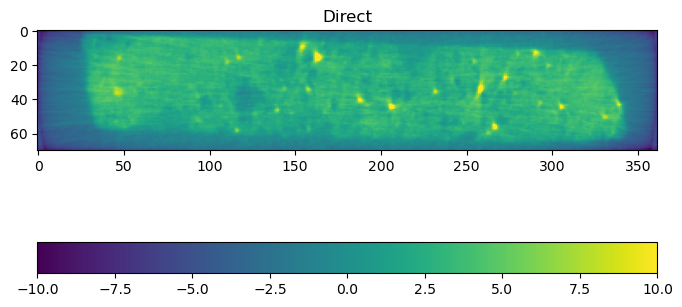

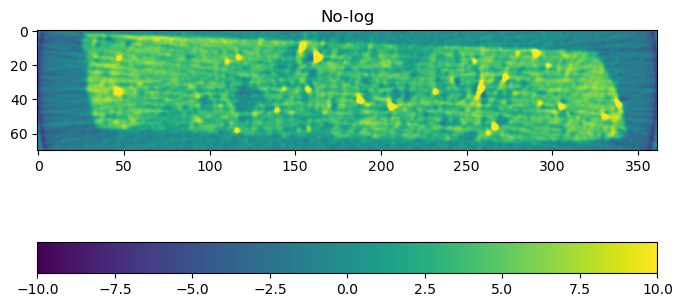

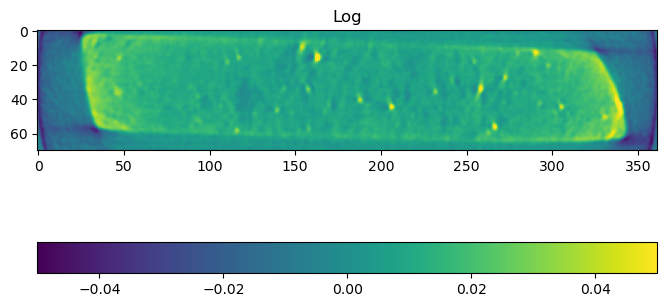

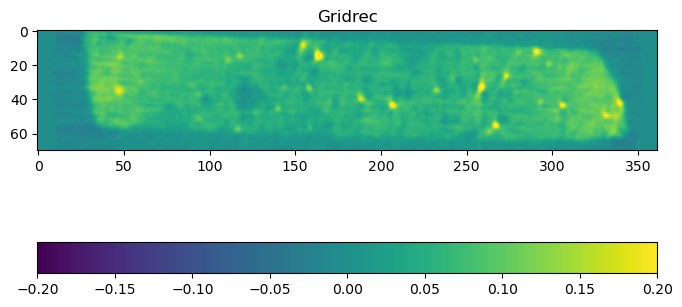

In [172]:
plt.figure(figsize=(8,8))
plt.imshow(recon[0]*1e+6)
plt.clim([-10,10])
plt.colorbar(orientation='horizontal')
plt.title('Direct')
#plt.clim([-50000,50000])
plt.show()
plt.figure(figsize=(8,8))
plt.imshow(recon_nolog[0]*1e6)
plt.colorbar(orientation='horizontal')
plt.title('No-log')
plt.clim([-10,10])
plt.show()
plt.figure(figsize=(8,8))
plt.imshow(recon_log[0])
plt.title('Log')
plt.clim([-0.05,0.05])
plt.colorbar(orientation='horizontal')
plt.show()
plt.figure(figsize=(8,8))
plt.imshow(recon_gridrec[0])
plt.title('Gridrec')
plt.clim([-0.2,0.2])
plt.colorbar(orientation='horizontal')
plt.show()

In [98]:
def mean_correlation(A1: np.ndarray, A2: np.ndarray) -> float:
    """
    Computes the mean correlation between corresponding data points A1[:, i, j] and A2[:, i, j].

    Parameters:
    A1, A2 (np.ndarray): Input 3D arrays with shape (d, n, n).

    Returns:
    float: Mean correlation over all (i, j) positions.
    """
    if A1.shape != A2.shape:
        raise ValueError("A1 and A2 must have the same shape")
    
    d, n, m = A1.shape
    correlations = np.zeros((n, m))
    
    for i in range(n):
        for j in range(m):
            corr = np.corrcoef(A1[:, i, j], A2[:, i, j])[0, 1]  # Compute correlation
            correlations[i, j] = corr if not np.isnan(corr) else 0  # Handle NaN values
    
    return np.mean(correlations)

In [ ]:
print(recon_log.shape)
print(mean_correlation(recon_gridrec, recon_nolog))
print(mean_correlation(recon_gridrec, recon_log))
print(mean_correlation(recon_gridrec, recon))
print(mean_correlation(recon, recon_log))
print(mean_correlation(recon, recon_nolog))



(200, 70, 362)


/zhome/71/c/146676/miniconda3/envs/cil5/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/zhome/71/c/146676/miniconda3/envs/cil5/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


0.8470901045033972
0.6852320203713564
0.6948106939474366
0.6896855418157362
0.80276022711673
